In [182]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import nltk
from nltk.corpus import stopwords,words
import re

In [185]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/yazdan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [2]:
pd.options.display.max_rows=2000

In [3]:
base_path='../data/clean'

In [4]:
#read cleaned data
products_df=pd.read_csv(f'{base_path}/products_cl.csv')
orders_df=pd.read_csv(f'{base_path}/orders_cl.csv')
brands_df=pd.read_csv(f'{base_path}/brands_cl.csv')
orderlines_df=pd.read_csv(f'{base_path}/orderlines_cl.csv')

In [5]:
orders_df['created_date']=pd.to_datetime(orders_df['created_date'])

In [6]:
orderlines_df['date']=pd.to_datetime(orderlines_df['date'])

### Discounts analysis

In [7]:
# Discount is the diffrence between the unit_price in orderlines and price in products
# we need to merge this two table together

In [8]:
products_df['sku'].nunique()

9992

In [9]:
orderlines_df['sku'].nunique()

5098

In [10]:
orderlines_df

,id,id_order,product_id,product_quantity,sku,unit_price,date
0,1119116,299545,0,1,OWC0100,47.49,2017-01-01 01:46:16
1,1119119,299546,0,1,IOT0014,18.99,2017-01-01 01:50:34
2,1119120,295347,0,1,APP0700,72.19,2017-01-01 01:54:11
3,1119134,299556,0,1,CRU0039-A,60.90,2017-01-01 02:20:14
4,1119145,299561,0,1,PEB0015,142.49,2017-01-01 02:38:50
...,...,...,...,...,...,...,...
53226,1649447,527035,0,1,APP0698,9.99,2018-03-14 11:42:41
53227,1649512,527070,0,2,APP0698,9.99,2018-03-14 11:49:01
53228,1649522,527074,0,2,APP0698,9.99,2018-03-14 11:49:36
53229,1649565,527096,0,3,APP0698,9.99,2018-03-14 11:54:35


In [11]:
ol_p_df=orderlines_df.merge(products_df,on='sku',how='left')

In [12]:
ol_p_df.columns

Index(['id', 'id_order', 'product_id', 'product_quantity', 'sku', 'unit_price',
       'date', 'name', 'desc', 'price', 'in_stock', 'type'],
      dtype='object')

In [13]:
ol_p_df.drop(['id','product_id','name','desc','in_stock','type'],axis=1,inplace=True)

In [14]:
ol_p_df.rename(columns={'product_quantity':'qty','id_order':'order_id'},inplace=True)

In [15]:
ol_p_df.rename(columns={'unit_price':'sale_price','price':'base_price'},inplace=True)

In [16]:
ol_p_df=ol_p_df[['date','order_id','sku','qty','base_price','sale_price']]

In [17]:
ol_p_df.loc[:,'discount']=ol_p_df['base_price']-ol_p_df['sale_price']

In [18]:
ol_p_df.loc[:,'discount_rate']=round(ol_p_df['discount']/ol_p_df['base_price'],3)

In [19]:
ol_p_df.loc[:,'date']=ol_p_df['date'].dt.date

In [20]:
ol_p_df.loc[:,'is_discounted']=True
ol_p_df.loc[ol_p_df['sale_price']>=ol_p_df['base_price'],'is_discounted']=False

In [21]:
ol_p_df.loc[:,'total_sale_price']=ol_p_df['sale_price']*ol_p_df['qty']

#### What is the time period that the dataset covers?

In [22]:
min_date=ol_p_df['date'].min().date()
max_date=ol_p_df['date'].max().date()

print(f'The dataset covers from {min_date} to {max_date}')

The dataset covers from 2017-01-01 to 2018-03-14


#### What is the overall revenue for that time?

In [23]:
overall_revenue=float(round((ol_p_df['qty']*ol_p_df['sale_price']).sum(),1))
overall_revenue

7817204.4

#### How many orders are there? How many items have been sold?

In [235]:
orders_df['order_id'].nunique()

40985

In [237]:
orderlines_df['product_quantity'].sum()

np.int64(60011)

#### Do discounted products lead to more sales ?

In [248]:
discounted_p=ol_p_df.groupby('is_discounted').agg(total_unit_sold=('qty','sum')).reset_index()
discounted_p['is_discounted'] = discounted_p['is_discounted'].map({
    True: 'With Discount',
    False: 'Without Discount'
})
total_units=discounted_p['total_unit_sold'].sum()
discounted_p['percentage'] = (discounted_p['total_unit_sold'] /total_units  * 100).round(1)

In [257]:
discounted_p

,is_discounted,total_unit_sold,percentage
0,Without Discount,4341,7.2
1,With Discount,55670,92.8


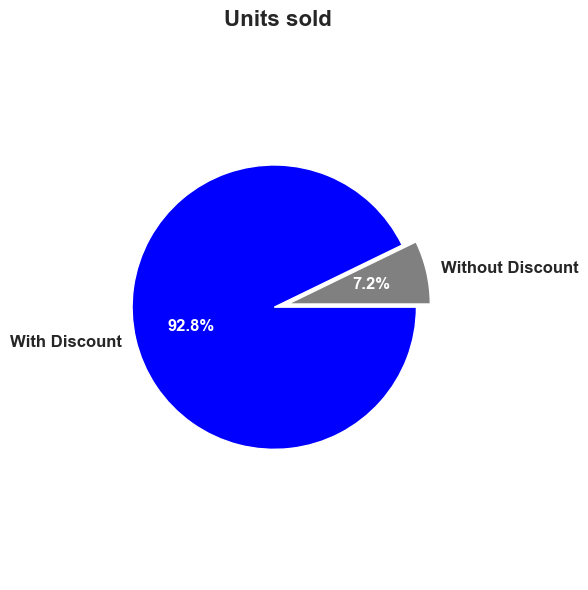

In [258]:
labels = list(discounted_p['is_discounted'])
sizes = [7.2,92.8]
colors = ['gray', 'blue']
explode = (0.05, 0.05)  

# Create the pie chart
plt.figure(figsize=(6, 6))
patches, texts, autotexts = plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',

    colors=colors,
    explode=explode,
    textprops={'fontsize': 12, 'weight': 'bold'}
)

# Make text more readable
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(12)

plt.title('Units sold ', fontsize=16, weight='bold')
plt.axis('equal')  # Equal aspect ratio ensures pie is drawn as a circle
plt.tight_layout()
plt.savefig('/Users/yazdan/Desktop/plots/unit_sold.png', dpi=300, bbox_inches='tight')


#### Do discounted products generate more or less total revenue?

In [262]:
discounted_r=ol_p_df.groupby('is_discounted').agg(total_revenue=('total_sale_price','sum')).reset_index()

In [263]:
discounted_r['is_discounted'] = discounted_r['is_discounted'].map({
    True: 'With Discount',
    False: 'Without Discount'
})
total_revenue=discounted_r['total_revenue'].sum()
discounted_r['percentage'] = (discounted_r['total_revenue'] /total_revenue  * 100).round(1)

In [264]:
discounted_r

,is_discounted,total_revenue,percentage
0,Without Discount,575080.98,7.4
1,With Discount,7242123.42,92.6


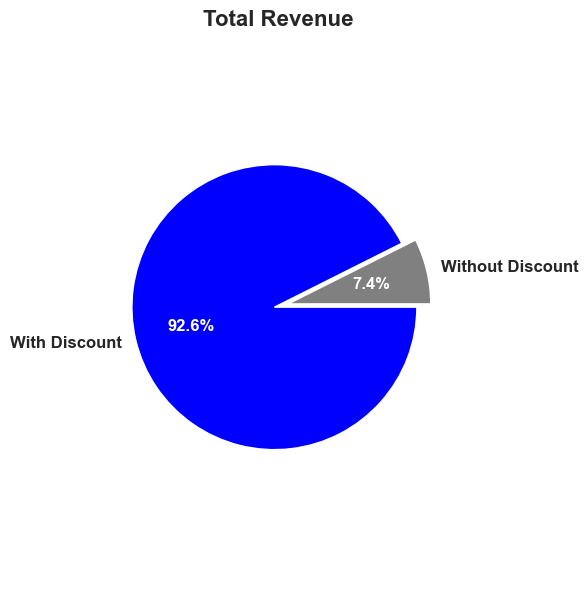

In [265]:
labels = list(discounted_r['is_discounted'])
sizes = [7.4,92.6]
colors = ['gray', 'blue']
explode = (0.05, 0.05)  

# Create the pie chart
plt.figure(figsize=(6, 6))
patches, texts, autotexts = plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',

    colors=colors,
    explode=explode,
    textprops={'fontsize': 12, 'weight': 'bold'}
)

# Make text more readable
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(12)

plt.title('Total Revenue ', fontsize=16, weight='bold')
plt.axis('equal')  # Equal aspect ratio ensures pie is drawn as a circle
plt.tight_layout()
plt.savefig('/Users/yazdan/Desktop/plots/revenue.png', dpi=300, bbox_inches='tight')

#### How big are the offered discounts as a percentage of the product prices?


In [29]:
float(round(ol_p_df['discount_rate'].mean(),2))

0.21

#### What are the most sold products? are they discounted or not? how is the discount rate of them?


In [30]:
ol_p_df.groupby(['sku','is_discounted']).agg(total_unit_sold=('qty','count'),avg_discount_rate=('discount_rate','mean')).nlargest(10,'total_unit_sold')

,,total_unit_sold,avg_discount_rate
sku,is_discounted,,
APP1190,True,860,0.224103
APP0698,True,478,0.599979
APP1922,True,449,0.113960
APP0927,True,378,0.509794
SAM0074,True,298,0.152453
WDT0183,True,289,0.183606
CRU0051,True,269,0.144814
APP2446,True,260,0.137908
APP1970,True,220,0.135859


#### What are the products that generate the most revenue? Are they discounted or not?

In [229]:
ol_p_df.groupby(['sku','is_discounted']).agg(total_revenue=('total_sale_price','sum'),avg_discount_rate=('discount_rate','mean')).nlargest(10,'total_revenue')

,,total_revenue,avg_discount_rate
sku,is_discounted,,
LGE0044,True,133575.86,0.053793
APP2446,True,104560.64,0.137908
APP2477,True,85301.93,0.023520
APP1970,True,80715.76,0.135859
APP1922,True,75196.26,0.113960
APP2072,True,74964.06,0.119303
APP2485,True,70721.79,0.026103
WDT0183,True,65589.96,0.183606
APP2483,True,60090.08,0.025226


#### Are there seasonal patterns in the evolution of sales?

In [32]:
ol_p_df.loc[:,'year']=ol_p_df['date'].dt.year
ol_p_df.loc[:,'month']=ol_p_df['date'].dt.month
ol_p_df.loc[:,'weekday']=ol_p_df['date'].dt.weekday

In [102]:
month_by_sale=ol_p_df.resample('MS',on='date').agg(count_sold_products=('qty','sum'),total_revenue=('total_sale_price','sum'))

In [103]:
month_by_sale

,count_sold_products,total_revenue
date,,
2017-01-01,6855,609260.70
2017-02-01,2918,327483.46
2017-03-01,246,25508.97
2017-04-01,2132,230379.32
2017-05-01,2573,331725.55
2017-06-01,2051,285107.03
2017-07-01,4625,603124.23
2017-08-01,3023,376329.62
2017-09-01,2788,393137.39


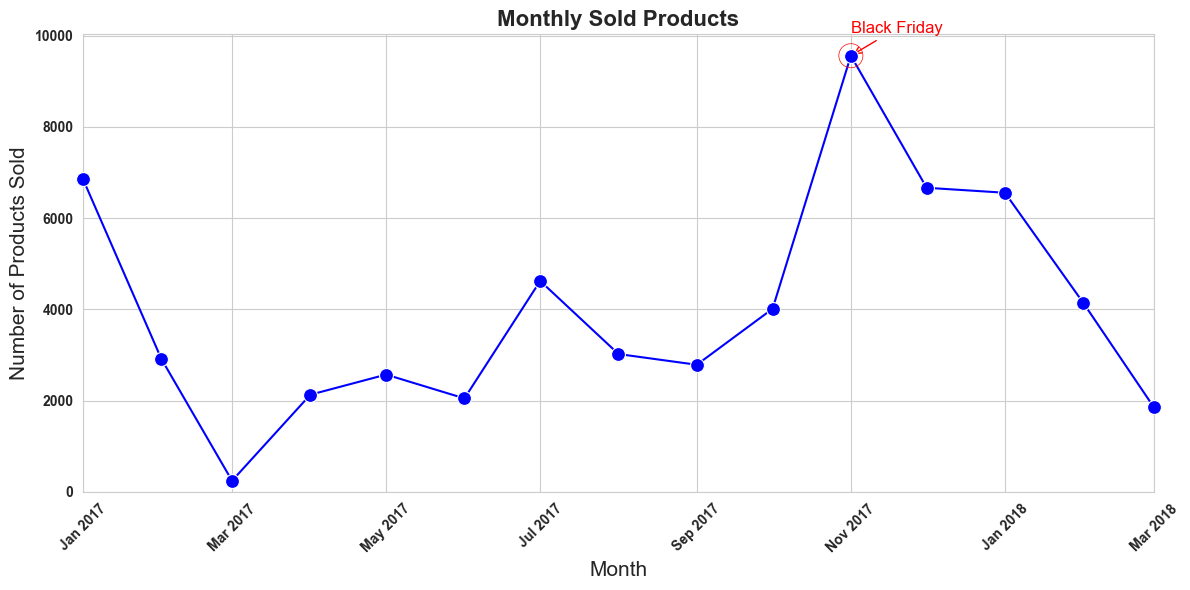

In [194]:
plt.figure(figsize=(12, 6))
sns.set_style('whitegrid')

# Plot the line (no markers)
ax=sns.lineplot(
    data=month_by_sale,
    x='date',
    y='count_sold_products',
    color='blue',
)

# Plot the markers separately
sns.scatterplot(
    data=month_by_sale,
    x='date',
    y='count_sold_products',
    color='blue',   # Marker color
    s=100,         # Marker size
    zorder=10,      # Draw on top of the line
    clip_on=False
)

# Find the max row in your DataFrame
max_row = month_by_sale.loc[month_by_sale['count_sold_products'].idxmax()]
max_date = max_row.name  # index should be datetime (after resample)
max_value = max_row['count_sold_products']
# Plot the circle around the max point
plt.scatter(
    [max_date], [max_value],
    s=300,           # Bigger size for the outer circle
    facecolors='none',
    edgecolors='red',
    linewidths= .5,
    zorder=10
)

# Annotate the point
plt.annotate(
    'Black Friday',
    xy=(max_date, max_value),
    xytext=(max_date, max_value + 500),  # Adjust label position above point
    arrowprops=dict(arrowstyle='->', color='red'),
    fontsize=12,
    color='red',
    ha='left'
)

# Axis formatting

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.title("Monthly Sold Products", fontsize=16,fontweight='bold')
plt.xlabel("Month",fontsize=15)
plt.ylabel("Number of Products Sold",fontsize=15)
plt.xticks(rotation=45,fontweight='bold')
plt.yticks(fontweight='bold')
plt.xlim(pd.to_datetime('2017-01-01'), pd.to_datetime('2018-03-01')) 
plt.ylim(bottom=0)
plt.tight_layout()
plt.savefig('/Users/yazdan/Desktop/plots/sold_products_by_month.png', dpi=300, bbox_inches='tight')

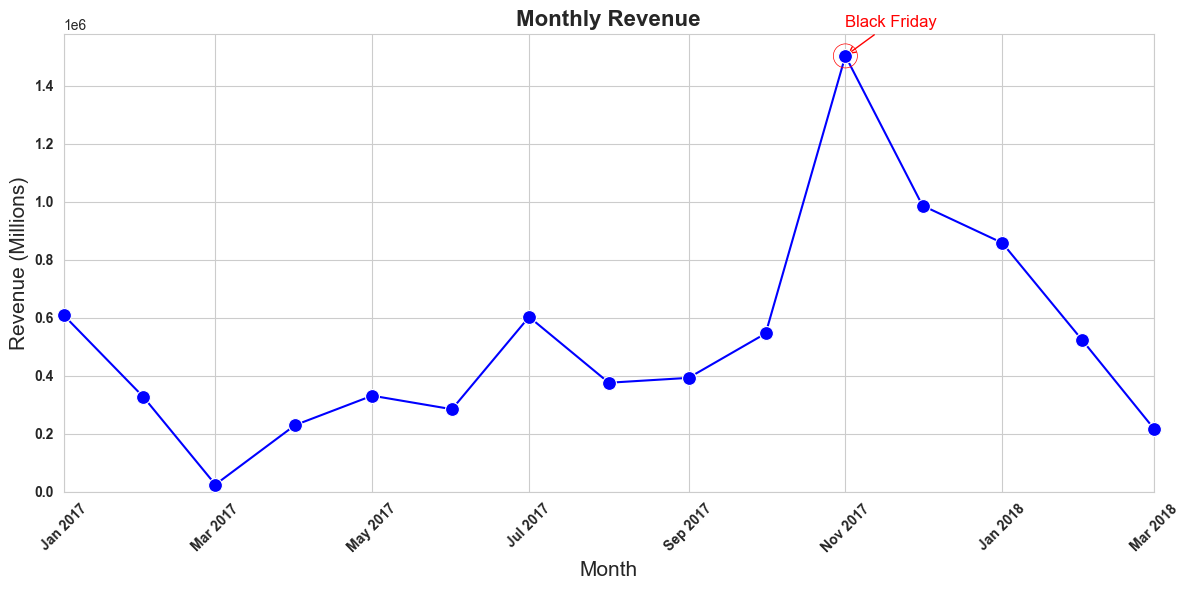

In [195]:
plt.figure(figsize=(12, 6))
sns.set_style('whitegrid')

# Plot the line (no markers)
ax=sns.lineplot(
    data=month_by_sale,
    x='date',
    y='total_revenue',
    color='blue',
)

# Plot the markers separately
sns.scatterplot(
    data=month_by_sale,
    x='date',
    y='total_revenue',
    color='blue',   # Marker color
    s=100,         # Marker size
    zorder=10,      # Draw on top of the line
    clip_on=False
)

# Find the max row in your DataFrame
max_row = month_by_sale.loc[month_by_sale['total_revenue'].idxmax()]
max_date = max_row.name  # index should be datetime (after resample)
max_value = max_row['total_revenue']
# Plot the circle around the max point
plt.scatter(
    [max_date], [max_value],
    s=300,           # Bigger size for the outer circle
    facecolors='none',
    edgecolors='red',
    linewidths= .5,
    zorder=10
)

# Annotate the point
plt.annotate(
    'Black Friday',
    xy=(max_date, max_value),
    xytext=(max_date, max_value + 100000),  # Adjust label position above point
    arrowprops=dict(arrowstyle='->', color='red'),
    fontsize=12,
    color='red',
    ha='left'
)

# Axis formatting

ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.title("Monthly Revenue", fontsize=16,fontweight='bold')
plt.xlabel("Month",fontsize=15)
plt.ylabel("Revenue (Millions)",fontsize=15)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.ylim(bottom=0)
plt.xticks(rotation=45,fontweight='bold')
plt.yticks(fontweight='bold')
plt.xlim(pd.to_datetime('2017-01-01'), pd.to_datetime('2018-03-01'))  
plt.tight_layout()
plt.savefig('/Users/yazdan/Desktop/plots/revenue_by_month.png', dpi=300, bbox_inches='tight')

#### How should products be classified into different categories to simplify reports and analysis?


In [206]:
products_df[products_df['type']=='11865403']['price'].describe()

count    1057.000000
mean       39.805799
std        20.720235
min         7.900000
25%        24.990000
50%        39.000000
75%        49.990000
max       149.990000
Name: price, dtype: float64

In [218]:

def create_category(type:str):
    desc_column=list(products_df.loc[products_df['type']==type]['desc'])
    words_dict={}
    for desc in desc_column:
        for sp in desc.split():
            sp=sp.lower()
            sp=re.sub(r'\d+', '', sp)
            if sp not in stopwords.words('english'):
                if sp.isalpha():
                    if sp not in words_dict:
                        words_dict[sp]=1
                    else:
                        words_dict[sp]+=1
    return max(words_dict, key=words_dict.get) if len(words_dict)>=1 else 'other'
            


#### What is the distribution of product prices across different categories?
